# Establish the multi-stage core formation of Major elements

## Overview
This notebook simulates the multi-stage core formation process during planetary accretion. 
It combines early compositional data with partial melting and collision equilibrium calculations.

## Key Steps
1. **Load initial compositions** - Early solar system embryo data
2. **Load collision events** - Partial melting parameters and collision scenarios
3. **Calculate equilibrium** - KD-based core-mantle differentiation
4. **Extract final compositions** - Determine planetary compositions after all collisions
5. **Visualize results** - X/MgO ratios and CI-normalized spider diagrams
6. **Export data** - Save results to Excel for further analysis

In [4]:
# ============================================================================
# CELL 1: Imports & Configuration
# ============================================================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import matplotlib.patches as mpatches

sys.path.append('../../src')  # Correct relative path to src module
import accrediff as ad

In [5]:
# ============================================================================
# CELL 2: Global Plotting Parameters (Nature Style)
# ============================================================================

# ──────────────────────────────────────────────────────
# Nature Style Parameters
# ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",        # Serif font
    "font.size": 12,               # Main font size
    "axes.linewidth": 1,           # Axis line width
    "axes.labelsize": 14,          # Axis label size
    "xtick.labelsize": 12,         # X-axis tick font size
    "ytick.labelsize": 12,         # Y-axis tick font size
    "xtick.direction": "in",       # Inward tick marks
    "ytick.direction": "in",
    "xtick.top": False,            # Remove top ticks
    "ytick.right": False,          # Remove right ticks
    "figure.dpi": 300              # High resolution
})

# ──────────────────────────────────────────────────────
# Color Configuration
# ──────────────────────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'IW15': "green",
    'IW35': "purple",
}

### Data Loading Summary
- **Source**: Early solar system embryo compositions
- **Format**: CSV with embryo IDs as index
- **Key columns**: Element abundances (MgO, FeO, SiO2, etc.), masses

In [ ]:
# ============================================================================
# CELL 3: Load Early Composition Data
# ============================================================================

Model = 'note_02'  # ⭐ Configurable parameter
data1_name = Model+'_early_composition.csv'
base1_path = '../Accrection/Tables'

# ── File path construction ───────────────────────────
path_com = os.path.join(base1_path, data1_name)

# ── File existence check ─────────────────────────────
if not os.path.exists(path_com):
    raise FileNotFoundError(f"Input file not found: {path_com}")

# ── Load data ────────────────────────────────────────
early_components = pd.read_csv(path_com, index_col=0)

print(f"✓ Loaded early composition: {path_com}")
print(f"  Rows    : {len(early_components)}")
print(f"  Columns : {list(early_components.columns)}")
print()

# ── Data structure check ─────────────────────────────
print(f"Sample data (first 3 rows):")
print(early_components.head(3))
print()

✓ Loaded early composition: ../Accrection/Tables/note_02_early_composition.csv
  Rows    : 1244
  Columns : ['i', 'a', 'e', 'inc', 'm_e', 'EF', 'EC', 'OC', 'CI', 'EF_ratio', 'EC_ratio', 'OC_ratio', 'CI_ratio', 'P', 'T', 'MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']

Sample data (first 3 rows):
      i         a         e       inc       m_e   EF   EC        OC        CI  \
0  6170  1.885426  0.055145  0.026060  0.000215  0.0  0.0  0.000215  0.000000   
1  5974  1.328577  0.136199  0.125076  0.000367  0.0  0.0  0.000367  0.000000   
2  5069  2.733346  0.174028  0.035980  0.000396  0.0  0.0  0.000000  0.000396   

   EF_ratio  ...       MgO     Al2O3       CaO       FeO       NiO      SiO2  \
0       0.0  ...  0.350476  0.012646  0.018756  0.170354  0.000206  0.372605   
1       0.0  ...  0.350476  0.012646  0.018756  0.170369  0.000207  0.372605   
2       0.0  ...  0.338081  0.013408  0.019577  0.280679  0.004247  0.328082   

         Fe        Ni            Si  

### Collision Data Structure
- **Event types**: 'small', 'global', 'partial'
- **Key parameters**: P_equil, T_equil, target_id, impactor_id
- **Optional fields**: k_mantle (mantle fraction for large impacts)

In [7]:
# ============================================================================
# CELL 4: Load Partial Melting and Collision Data
# ============================================================================

data2_name = Model+'_giant_impact.xlsx'
base2_path = '../Impact/Tables'
# ── File path construction ───────────────────────────
path_partial_melting = os.path.join(base2_path, data2_name)

# ── File existence check ─────────────────────────────
if not os.path.exists(path_partial_melting):
    raise FileNotFoundError(f"Input file not found: {path_partial_melting}")

# ── Load data (all sheets) ───────────────────────────
partial_dict = pd.read_excel(path_partial_melting, sheet_name=None)

print(f"✓ Loaded partial melting data: {path_partial_melting}")
print(f"  Sheets  : {len(partial_dict)}")
print(f"  Sheet names: {list(partial_dict.keys())}")
print()

# ── Data structure check ─────────────────────────────
sample_sheet = list(partial_dict.keys())[0]
sample_df = partial_dict[sample_sheet]

print(f"Sample dataset structure ({sample_sheet}):")
print(f"  Rows    : {len(sample_df)}")
print(f"  Columns : {list(sample_df.columns)}")
print(f"  Event types: {sample_df['events'].unique()}")
print()

✓ Loaded partial melting data: ../Impact/Tables/note_02_giant_impact.xlsx
  Sheets  : 3
  Sheet names: ['planets_1', 'planets_2', 'planets_3']

Sample dataset structure (planets_1):
  Rows    : 142
  Columns : ['Time', 'target_id', 'impactor_id', 'm_target', 'm_impactor', 'Mass', 'Impact ratio', 'events', 'P_equil', 'T_equil', 'k_mantle']
  Event types: ['small' 'partial' 'global']



### Element Classification
- **Mantle phases**: Oxide compounds (MgO, Al2O3, CaO, FeO, NiO, SiO2)
- **Core phases**: Pure elements (Fe, Ni, Si, O)
- These are used for visualization and KD-based equilibration

In [9]:
# ============================================================================
# CELL 5: Define Major Elements and Categories
# ============================================================================

# ── Major elements list ──────────────────────────────
major_elements = ['i', 'm_e',
                  'MgO', 'Al2O3', 'CaO',
                  'FeO', 'NiO', 'SiO2',
                  'Fe', 'Ni', 'Si', 'O']

# ── Element classification ──────────────────────────
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items = ['Fe', 'Ni', 'Si', 'O']

print(f"✓ Element configuration defined")
print(f"  Total elements : {len(major_elements)}")
print(f"  Mantle items   : {len(mantle_items)}")
print(f"  Core items     : {len(core_items)}")
print()

✓ Element configuration defined
  Total elements : 12
  Mantle items   : 6
  Core items     : 4



### Collision Event Processing
This step processes each collision according to its type:
- **Small impact**: Impactor core sinks; mantle re-equilibrates (f_core = 0.7)
- **Global impact**: Entire mantle re-equilibrates; core partially sinks (k_mantle fraction)
- **Partial impact**: Between small and global; controlled re-equilibration (k_mantle, f_core = 0.3)

In [11]:
# ============================================================================
# CELL 6: Core Processing - Multi-Collision Event Simulation
# ============================================================================

# ── Initialize storage structure ─────────────────────
df_dict = {}

print(f"✓ Processing collision-equilibrium events:")
print()

# ── Main loop: iterate over all collision scenarios ──
for key in partial_dict.keys():
    df = partial_dict[key]
    
    # ── Step 1: Extract initial compositions ─────────
    target_ids = df['target_id'].unique()
    impactor_ids = df['impactor_id'].unique()
    id_set = set(target_ids) | set(impactor_ids)
    id_list = list(id_set)
    
    # Filter required initial compositions
    filtered_components = early_components[early_components['i'].isin(id_list)][major_elements]
    filtered_components.set_index('i', inplace=True)
    col_list = filtered_components.columns.tolist()
    
    # ── Step 2: Initialize result storage ────────────
    df_var = pd.DataFrame(columns=['Time', 'target_id'] + col_list)
    
    # ── Step 3: Process collision events row by row ───
    for num in df.index:
        t = df['Time'].iloc[num]
        P_equil = df.loc[num, 'P_equil']
        T_equil = df.loc[num, 'T_equil']
        target_id = df.loc[num, 'target_id']
        impactor_id = df.loc[num, 'impactor_id']
        event_type = df.loc[num, 'events']
        
        # ── Calculate partition coefficients ─────────
        kd_calc = ad.KDCalculator()
        KD_Ni = kd_calc.get_KD('Ni', P_equil, T_equil)
        KD_Si = kd_calc.get_KD('Si', P_equil, T_equil)
        KD_O = kd_calc.get_KD('O', P_equil, T_equil)
        
        # ── Retrieve impactor and target compositions ─
        target_comp = filtered_components[filtered_components.index == target_id].copy()
        impactor_comp = filtered_components[filtered_components.index == impactor_id].copy()
        
        mass_target = target_comp['m_e'].values[0]
        mass_impactor = impactor_comp['m_e'].values[0]
        total_mass = mass_target + mass_impactor
        
        # ── Step 4: Partition by collision type ──────
        if event_type == 'small':
            f_core_pl = 0.7
            # Non-equilibrating material (not affected by KD)
            bulk_no_re_eq = {
                'MgO': target_comp['MgO'].values[0]*mass_target,
                'Al2O3': target_comp['Al2O3'].values[0]*mass_target,
                'CaO': target_comp['CaO'].values[0]*mass_target,
                'FeO': target_comp['FeO'].values[0]*mass_target,
                'NiO': target_comp['NiO'].values[0]*mass_target,
                'SiO2': target_comp['SiO2'].values[0]*mass_target,
                'Fe': target_comp['Fe'].values[0]*mass_target + impactor_comp['Fe'].values[0]*mass_impactor * (1-f_core_pl),
                'Ni': target_comp['Ni'].values[0]*mass_target + impactor_comp['Ni'].values[0]*mass_impactor * (1-f_core_pl),
                'Si': target_comp['Si'].values[0]*mass_target + impactor_comp['Si'].values[0]*mass_impactor * (1-f_core_pl),
                'O': target_comp['O'].values[0]*mass_target + impactor_comp['O'].values[0]*mass_impactor * (1-f_core_pl),
            }
            # Equilibrating material (subject to KD partitioning)
            bulk_re_eq = {
                'MgO': impactor_comp['MgO'].values[0]*mass_impactor,
                'Al2O3': impactor_comp['Al2O3'].values[0]*mass_impactor,
                'CaO': impactor_comp['CaO'].values[0]*mass_impactor,
                'FeO': impactor_comp['FeO'].values[0]*mass_impactor,
                'NiO': impactor_comp['NiO'].values[0]*mass_impactor,
                'SiO2': impactor_comp['SiO2'].values[0]*mass_impactor,
                'Fe': impactor_comp['Fe'].values[0]*mass_impactor*f_core_pl,
                'Ni': impactor_comp['Ni'].values[0]*mass_impactor*f_core_pl,
                'Si': impactor_comp['Si'].values[0]*mass_impactor*f_core_pl,
                'O': impactor_comp['O'].values[0]*mass_impactor*f_core_pl,
            }
            
        elif event_type == 'global':
            k_mantle = df['k_mantle'].iloc[num]
            f_mantle = 0.05
            f_core_pl = 0.7
            # Non-equilibrating material
            bulk_no_re_eq = {
                'MgO': target_comp['MgO'].values[0]*mass_target*(1 - k_mantle*f_mantle),
                'Al2O3': target_comp['Al2O3'].values[0]*mass_target*(1 - k_mantle*f_mantle),
                'CaO': target_comp['CaO'].values[0]*mass_target*(1 - k_mantle*f_mantle),
                'FeO': target_comp['FeO'].values[0]*mass_target*(1 - k_mantle*f_mantle),
                'NiO': target_comp['NiO'].values[0]*mass_target*(1 - k_mantle*f_mantle),
                'SiO2': target_comp['SiO2'].values[0]*mass_target*(1 - k_mantle*f_mantle),
                'Fe': target_comp['Fe'].values[0]*mass_target + impactor_comp['Fe'].values[0]*mass_impactor * (1-f_core_pl),
                'Ni': target_comp['Ni'].values[0]*mass_target + impactor_comp['Ni'].values[0]*mass_impactor * (1-f_core_pl),
                'Si': target_comp['Si'].values[0]*mass_target + impactor_comp['Si'].values[0]*mass_impactor * (1-f_core_pl),
                'O': target_comp['O'].values[0]*mass_target + impactor_comp['O'].values[0]*mass_impactor * (1-f_core_pl),
            }
            # Equilibrating material
            bulk_re_eq = {
                'MgO': impactor_comp['MgO'].values[0]*mass_impactor + target_comp['MgO'].values[0]*mass_target*k_mantle*f_mantle,
                'Al2O3': impactor_comp['Al2O3'].values[0]*mass_impactor + target_comp['Al2O3'].values[0]*mass_target*k_mantle*f_mantle,
                'CaO': impactor_comp['CaO'].values[0]*mass_impactor + target_comp['CaO'].values[0]*mass_target*k_mantle*f_mantle,
                'FeO': impactor_comp['FeO'].values[0]*mass_impactor + target_comp['FeO'].values[0]*mass_target*k_mantle*f_mantle,
                'NiO': impactor_comp['NiO'].values[0]*mass_impactor + target_comp['NiO'].values[0]*mass_target*k_mantle*f_mantle,
                'SiO2': impactor_comp['SiO2'].values[0]*mass_impactor + target_comp['SiO2'].values[0]*mass_target*k_mantle*f_mantle,
                'Fe': impactor_comp['Fe'].values[0]*mass_impactor*f_core_pl,
                'Ni': impactor_comp['Ni'].values[0]*mass_impactor*f_core_pl,
                'Si': impactor_comp['Si'].values[0]*mass_impactor*f_core_pl,
                'O': impactor_comp['O'].values[0]*mass_impactor*f_core_pl,
            }
            
        elif event_type == 'partial':
            k_mantle = df['k_mantle'].iloc[num]
            f_core = 0.3
            # Non-equilibrating material
            bulk_no_re_eq = {
                'MgO': target_comp['MgO'].values[0]*mass_target*(1 - k_mantle),
                'Al2O3': target_comp['Al2O3'].values[0]*mass_target*(1 - k_mantle),
                'CaO': target_comp['CaO'].values[0]*mass_target*(1 - k_mantle),
                'FeO': target_comp['FeO'].values[0]*mass_target*(1 - k_mantle),
                'NiO': target_comp['NiO'].values[0]*mass_target*(1 - k_mantle),
                'SiO2': target_comp['SiO2'].values[0]*mass_target*(1 - k_mantle),
                'Fe': target_comp['Fe'].values[0]*mass_target + impactor_comp['Fe'].values[0]*mass_impactor * (1-f_core),
                'Ni': target_comp['Ni'].values[0]*mass_target + impactor_comp['Ni'].values[0]*mass_impactor * (1-f_core),
                'Si': target_comp['Si'].values[0]*mass_target + impactor_comp['Si'].values[0]*mass_impactor * (1-f_core),
                'O': target_comp['O'].values[0]*mass_target + impactor_comp['O'].values[0]*mass_impactor * (1-f_core),
            }
            # Equilibrating material
            bulk_re_eq = {
                'MgO': impactor_comp['MgO'].values[0]*mass_impactor + target_comp['MgO'].values[0]*mass_target*k_mantle,
                'Al2O3': impactor_comp['Al2O3'].values[0]*mass_impactor + target_comp['Al2O3'].values[0]*mass_target*k_mantle,
                'CaO': impactor_comp['CaO'].values[0]*mass_impactor + target_comp['CaO'].values[0]*mass_target*k_mantle,
                'FeO': impactor_comp['FeO'].values[0]*mass_impactor + target_comp['FeO'].values[0]*mass_target*k_mantle,
                'NiO': impactor_comp['NiO'].values[0]*mass_impactor + target_comp['NiO'].values[0]*mass_target*k_mantle,
                'SiO2': impactor_comp['SiO2'].values[0]*mass_impactor + target_comp['SiO2'].values[0]*mass_target*k_mantle,
                'Fe': impactor_comp['Fe'].values[0]*mass_impactor*f_core,
                'Ni': impactor_comp['Ni'].values[0]*mass_impactor*f_core,
                'Si': impactor_comp['Si'].values[0]*mass_impactor*f_core,
                'O': impactor_comp['O'].values[0]*mass_impactor*f_core,
            }
        
        # ── Step 5: Build solver parameters ──────────
        Mg_total = bulk_re_eq['MgO']
        Al_total = 2*bulk_re_eq['Al2O3']
        Ca_total = bulk_re_eq['CaO']
        Fe_total = bulk_re_eq['FeO'] + bulk_re_eq['Fe']
        Ni_total = bulk_re_eq['NiO'] + bulk_re_eq['Ni']
        Si_total = bulk_re_eq['SiO2'] + bulk_re_eq['Si']
        O_L = bulk_re_eq['Fe'] + bulk_re_eq['Ni'] + 2*bulk_re_eq['Si'] - bulk_re_eq['O']
        
        params_dict = {
            'Fe_t': Fe_total,
            'Ni_t': Ni_total,
            'Si_t': Si_total,
            'O_L': O_L,
            'KD_Ni': KD_Ni,
            'KD_Si': KD_Si,
            'u': Mg_total,
            'm': Al_total,
            'n': Ca_total,
        }
        
        # ── Step 6: Solve KD-O equation ──────────────
        p0 = ad.KD_Params(**params_dict)
        solver = ad.ForwardKDOSolver(
            p0,
            nonneg='clip',
            enforce_z_box=True,
            enforce_d_nonneg=True,
        )
        res = solver.solve_x_for_KD_O(KD_O, tol=1e-12, max_iter=300, grid_N=400)
        res_dict = vars(res)
        
        # ── Step 7: Update target composition ─────────
        bulk = {
            'm_e': mass_target + mass_impactor,
            'MgO': (bulk_no_re_eq['MgO'] + params_dict['u']) / total_mass,
            'Al2O3': (bulk_no_re_eq['Al2O3'] + params_dict['m']/2) / total_mass,
            'CaO': (bulk_no_re_eq['CaO'] + params_dict['n']) / total_mass,
            'FeO': (bulk_no_re_eq['FeO'] + res_dict['x_']) / total_mass,
            'NiO': (bulk_no_re_eq['NiO'] + res_dict['y_']) / total_mass,
            'SiO2': (bulk_no_re_eq['SiO2'] + res_dict['z_']) / total_mass,
            'Fe': (bulk_no_re_eq['Fe'] + res_dict['a_']) / total_mass,
            'Ni': (bulk_no_re_eq['Ni'] + res_dict['b_']) / total_mass,
            'Si': (bulk_no_re_eq['Si'] + res_dict['c_']) / total_mass,
            'O': (bulk_no_re_eq['O'] + res_dict['d_']) / total_mass,
        }
        
        # Update component library and results
        for k, v in bulk.items():
            filtered_components.loc[target_id, k] = v
            df_var.loc[num, k] = v
        df_var.loc[num, 'Time'] = t
        df_var.loc[num, 'target_id'] = target_id
    
    df_dict[key] = df_var
    
    # ── Progress report ──────────────────────────────
    n_small = (df['events'] == 'small').sum()
    n_global = (df['events'] == 'global').sum()
    n_partial = (df['events'] == 'partial').sum()
    
    print(f"  {key:20s}: {len(df):4d} events | small: {n_small:3d} | global: {n_global:3d} | partial: {n_partial:3d}")

print()

✓ Processing collision-equilibrium events:

  planets_1           :  142 events | small: 139 | global:   2 | partial:   1
  planets_2           :   96 events | small:  84 | global:   9 | partial:   3
  planets_3           :   26 events | small:  26 | global:   0 | partial:   0



### Final Compositions
The last row from each collision scenario represents the final planetary composition.
This DataFrame will be used for visualization and analysis.

In [13]:
# ============================================================================
# CELL 7: Extract Final Planetary Compositions
# ============================================================================

# ── Initialize results DataFrame ─────────────────────
df_planets = pd.DataFrame()

print(f"✓ Extracting final planetary compositions:")
print()

# ── Extract last row from each collision scenario ────
for key, df in df_dict.items():
    if not df.empty:
        last_row = df.iloc[[-1]].copy()
        last_row = last_row[['Time', 'target_id'] + col_list]
        
        if df_planets.empty:
            df_planets = last_row
        else:
            df_planets = pd.concat([df_planets, last_row], ignore_index=True)
    
    n_planets = len(df_planets)
    print(f"  {key:20s}: extracted | cumulative planets: {n_planets}")

print()
print(f"Total final compositions: {len(df_planets)}")
print()

✓ Extracting final planetary compositions:

  planets_1           : extracted | cumulative planets: 1
  planets_2           : extracted | cumulative planets: 2
  planets_3           : extracted | cumulative planets: 3

Total final compositions: 3



### Figure 1: X/MgO Ratio
Shows normalized element abundances relative to MgO.
Marker size is proportional to planetary mass.
Helps identify compositional differences between final planets.

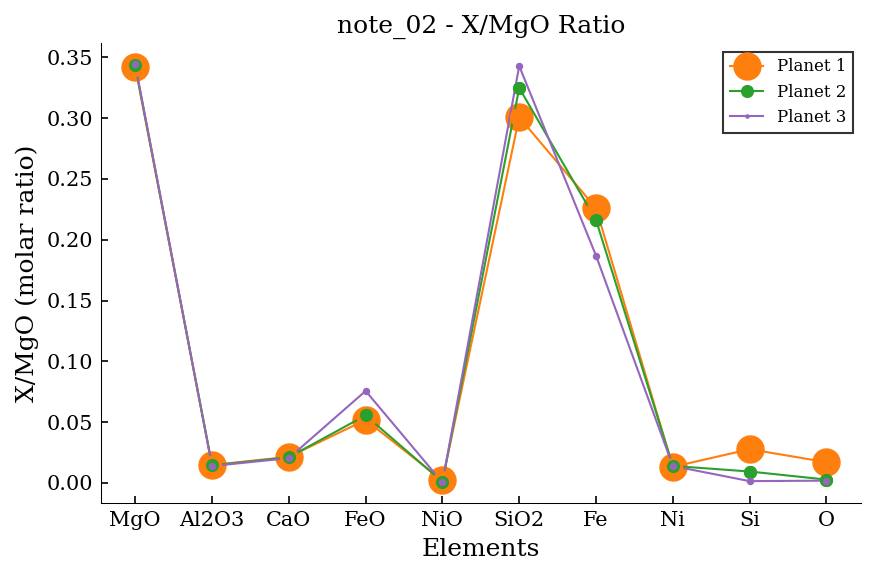

✓ Figure 1: X/MgO ratio displayed



In [15]:
# ============================================================================
# CELL 8: Visualization 1 - X/MgO Ratio Plot
# ============================================================================

# ── Prepare data and plotting parameters ──────────
embryos_id = [f'Planet {i+1}' for i in range(len(df_planets))]
cmap = plt.get_cmap('tab10')
n_embryos = len(df_planets)

# Select colors (skip unsuitable colors)
color_indices = [i for i in range(10) if i not in (0, 3)]
embryo_colors = [cmap(color_indices[i % len(color_indices)]) for i in range(n_embryos)]

major_items = mantle_items + core_items

# ── Create plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

for i in range(len(df_planets)):
    x = df_planets[major_items].iloc[i].index
    y = df_planets[major_items].iloc[i].values
    m = df_planets['m_e'].iloc[i]
    
    ax.plot(x, y, marker="o", linewidth=1, markersize=15*m,
            label=embryos_id[i], color=embryo_colors[i], zorder=2)
    ax.scatter(x, y, s=80*m, color=embryo_colors[i], zorder=3)

# ── Style formatting ─────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.set_xlabel("Elements", fontsize=12)
ax.set_ylabel("X/MgO (molar ratio)", fontsize=12)
ax.set_title(f"{Model} - X/MgO Ratio", fontsize=12, pad=5)
ax.tick_params(labelsize=10)

# ── Legend ───────────────────────────────────────
ax.legend(fontsize=8, loc='upper right', frameon=True, edgecolor='black', fancybox=False)

plt.tight_layout()
plt.show()

print(f"✓ Figure 1: X/MgO ratio displayed")
print()

### Figure 2: CI-normalized Spider Diagram
- **Mantle phases** (■): Oxide compounds normalized to CI chondrites
- **Core phases** (●): Pure elements normalized to CI chondrites
- **Reference line**: Chondritic composition (log ratio = 0)
- **Marker size**: Proportional to planetary mass

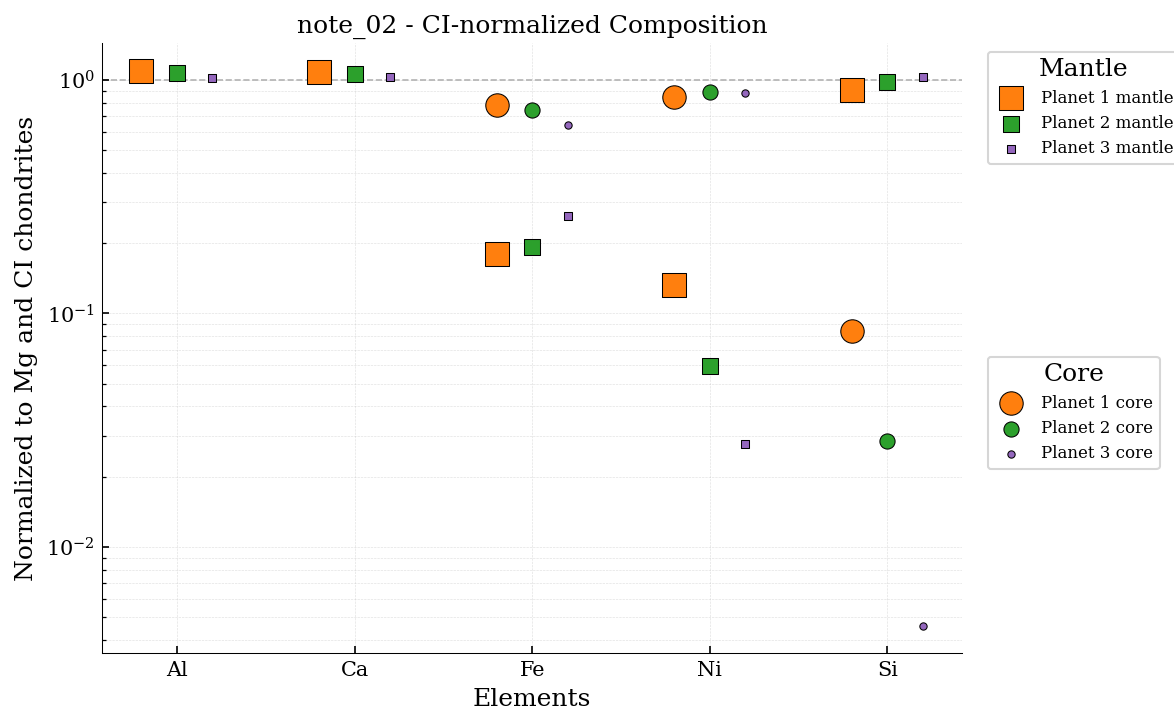

✓ Figure 2: CI-normalized spider diagram displayed



In [17]:
# ============================================================================
# CELL 9: Visualization 2 - CI-normalized Spider Diagram
# ============================================================================

# ── Step 1: Normalize to MgO ─────────────────────
df_planets_Mg = df_planets[major_items].copy()
df_planets_Mg = df_planets_Mg.div(df_planets['MgO'], axis=0)

# ── Step 2: Normalize to CI chondrites ────────────
CI_bulk_mg = ad.constants.CI_bulk_mg
df_CI_bulk_mg = pd.DataFrame([CI_bulk_mg], columns=CI_bulk_mg.keys())

df_planets_CI = df_planets_Mg[major_items[1:-1]].copy()
df_planets_CI[mantle_items[1:]] = df_planets_CI[mantle_items[1:]].div(df_CI_bulk_mg[mantle_items[1:]].values[0])
df_planets_CI[core_items[:-1]] = df_planets_CI[core_items[:-1]].div(df_CI_bulk_mg[mantle_items[3:]].values[0])

# ── Step 3: Create spider diagram ────────────────
elements = ['Al', 'Ca', 'Fe', 'Ni', 'Si']
mantle_keys = ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_keys = ['Fe', 'Ni', 'Si']

x_idx = np.arange(len(elements))
xx_idx = np.array([2, 3, 4])  # Indices for Fe, Ni, Si

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# Assign offsets for each planet
offsets = np.linspace(-0.2, 0.2, len(df_planets_CI))

for i in range(len(df_planets_CI)):
    # Plot mantle (squares)
    x_mantle = x_idx + offsets[i]
    y_mantle = df_planets_CI[mantle_keys].iloc[i].values
    ax.scatter(x_mantle, y_mantle, marker="s", s=150*df_planets['m_e'].iloc[i],
               label=f'{embryos_id[i]} mantle', color=embryo_colors[i],
               edgecolor='black', linewidth=0.5, zorder=3)
    
    # Plot core (circles)
    x_core = xx_idx + offsets[i]
    y_core = df_planets_CI[core_keys].iloc[i].values
    ax.scatter(x_core, y_core, marker="o", s=150*df_planets['m_e'].iloc[i],
               label=f'{embryos_id[i]} core', color=embryo_colors[i],
               edgecolor='black', linewidth=0.5, zorder=3)

# ── Style formatting ─────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.set_yscale("log")
ax.set_xticks(x_idx)
ax.set_xticklabels(elements, fontsize=12)
ax.set_ylabel("Normalized to Mg and CI chondrites", fontsize=12)
ax.set_xlabel("Elements", fontsize=12)
ax.set_title(f"{Model} - CI-normalized Composition", fontsize=12, pad=5)
ax.tick_params(labelsize=10)

# Reference line and grid
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, zorder=1)
ax.grid(True, which="both", ls="--", lw=0.3, alpha=0.4, zorder=0)

# ── Legend (grouped) ─────────────────────────────
handles, labels = ax.get_legend_handles_labels()
mantle_handles = [h for h, l in zip(handles, labels) if "mantle" in l]
mantle_labels = [l for l in labels if "mantle" in l]
core_handles = [h for h, l in zip(handles, labels) if "core" in l]
core_labels = [l for l in labels if "core" in l]

first_legend = ax.legend(mantle_handles, mantle_labels, title="Mantle",
                         bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.add_artist(first_legend)
ax.legend(core_handles, core_labels, title="Core",
          bbox_to_anchor=(1.02, 0.5), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print(f"✓ Figure 2: CI-normalized spider diagram displayed")
print()

### Export Summary
All collision event results are saved to a multi-sheet Excel file.
Each sheet represents one collision scenario with time evolution.

In [18]:
# ============================================================================
# CELL 10: Export Results to Excel
# ============================================================================

save_dir = './Tables'
os.makedirs(save_dir, exist_ok=True)
save_file = os.path.join(save_dir, f'{Model}_core_formation.xlsx')

# ── Write to Excel ───────────────────────────────
with pd.ExcelWriter(save_file) as writer:
    for key, df in df_dict.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"✅ Exported: {save_file}")
print(f"  Sheets    : {len(df_dict)}")
print(f"  Sheet names: {list(df_dict.keys())}")
print()

# ── File verification ────────────────────────────
file_size_mb = os.path.getsize(save_file) / (1024 ** 2)
print(f"  File size : {file_size_mb:.2f} MB")
print()

✅ Exported: ./Tables/note_02_core_formation.xlsx
  Sheets    : 3
  Sheet names: ['planets_1', 'planets_2', 'planets_3']

  File size : 0.05 MB



### Verification Complete ✅
All data has been successfully processed and exported.
Ready for further analysis or publication.

In [19]:
# ============================================================================
# CELL 11: Data Verification & Integrity Check
# ============================================================================

# ── Reload exported data ─────────────────────────
df_dict_reload = pd.read_excel(save_file, sheet_name=None)

print(f"✓ Verification: Reloaded {save_file}")
print(f"  Sheets loaded: {len(df_dict_reload)}")
print(f"  Sheet names  : {list(df_dict_reload.keys())}")
print()

# ── Sample inspection ────────────────────────────
sample_sheet = list(df_dict_reload.keys())[0]
df_sample = df_dict_reload[sample_sheet]

print(f"Sample sheet analysis ({sample_sheet}):")
print(f"  Total rows     : {len(df_sample)}")
print(f"  Total columns  : {len(df_sample.columns)}")
print(f"  Columns        : {list(df_sample.columns)}")
print()

# ── Statistical information ─────────────────────
print(f"First and last rows comparison:")
print(f"  First row target_id: {df_sample['target_id'].iloc[0]}")
print(f"  Last row target_id : {df_sample['target_id'].iloc[-1]}")
print()

print(f"✅ Verification complete - all data intact")
print()

✓ Verification: Reloaded ./Tables/note_02_core_formation.xlsx
  Sheets loaded: 3
  Sheet names  : ['planets_1', 'planets_2', 'planets_3']

Sample sheet analysis (planets_1):
  Total rows     : 142
  Total columns  : 13
  Columns        : ['Time', 'target_id', 'm_e', 'MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']

First and last rows comparison:
  First row target_id: 6604
  Last row target_id : 4189

✅ Verification complete - all data intact

